In [1]:
import numpy as np
import networkx as nx
from numba import njit
import matplotlib.pyplot as plt

In [2]:
# --- 1. PRE-PROCESSING (Run once per graph) ---
def prepare_graph_numba(G, highest=True, m0=0.0):
    """
    Converts NetworkX graph to Numba-friendly arrays.
    Returns: (adj_indices, adj_offsets, adj_edge_ids, edges_table, 
              reset_state, reset_active_count, reset_active_list, reset_pos_map)
    """
    N = G.number_of_nodes()
    M = G.number_of_edges()
    nodes = list(G.nodes())
    node_map = {n: i for i, n in enumerate(nodes)}
    
    # 1. Edge Indexing: Give every edge a unique ID from 0 to M-1
    edges_list = list(G.edges())
    edge_map_py = {tuple(sorted((node_map[u], node_map[v]))): i for i, (u, v) in enumerate(edges_list)}
    
    # Create lookup table: edge_id -> (u, v)
    edges_table = np.zeros((M, 2), dtype=np.int32)
    for (u, v), idx in edge_map_py.items():
        edges_table[idx] = (u, v)

    # 2. CSR-like Adjacency Construction
    # We store neighbors AND the edge_id connecting them
    adj_indices = []
    adj_edge_ids = []
    adj_offsets = np.zeros(N + 1, dtype=np.int32)
    
    current_offset = 0
    for i in range(N):
        u_node = nodes[i]
        neighbors = list(G[u_node])
        adj_offsets[i] = current_offset
        for v_node in neighbors:
            v = node_map[v_node]
            adj_indices.append(v)
            # Find the edge ID for (u, v)
            edge_key = tuple(sorted((i, v)))
            adj_edge_ids.append(edge_map_py[edge_key])
            current_offset += 1
    adj_offsets[N] = current_offset
    
    adj_indices = np.array(adj_indices, dtype=np.int32)
    adj_edge_ids = np.array(adj_edge_ids, dtype=np.int32)
    
    # 3. Pre-calculate Reset State
    nodes_sorted = sorted(nodes, key=lambda n: G.degree(n), reverse=highest)
    cutoff = int((1 + m0) * N / 2)
    reset_state = np.full(N, -1, dtype=np.int8)
    for i, node in enumerate(nodes_sorted):
        if i < cutoff:
            reset_state[node_map[node]] = 1

    # 4. Pre-calculate Reset Active Edges
    # active_list stores edge_ids
    # pos_map stores the position of an edge_id in active_list (-1 if inactive)
    reset_active_list = np.zeros(M, dtype=np.int32)
    reset_pos_map = np.full(M, -1, dtype=np.int32)
    count = 0
    
    for i in range(M):
        u, v = edges_table[i]
        if reset_state[u] != reset_state[v]:
            reset_active_list[count] = i
            reset_pos_map[i] = count
            count += 1
            
    return (adj_indices, adj_offsets, adj_edge_ids, edges_table, 
            reset_state, count, reset_active_list, reset_pos_map)

@njit
def run_fpt_numba(t_limit, r, m0, N, M, 
                  adj_indices, adj_offsets, adj_edge_ids, edges_table,
                  reset_state, reset_active_count, reset_active_list, reset_pos_map):
    
    # --- Initialize State ---
    states = np.empty(N, dtype=np.int8)
    for i in range(N):
        states[i] = 1 if np.random.random() < (1 + m0) / 2 else -1

    # --- Initialize Active Edges ---
    active_list = np.zeros(M, dtype=np.int32)
    pos_map = np.full(M, -1, dtype=np.int32)
    num_active = 0
    
    for i in range(M):
        u, v = edges_table[i]
        if states[u] != states[v]:
            active_list[num_active] = i
            pos_map[i] = num_active
            num_active += 1
            
    tt = 0.0
    
    # If we start in consensus, time is 0
    if num_active == 0:
        return 0.0

    # --- Evolution Loop ---
    while tt < t_limit:
        w = 2.0 * num_active
        la = w + r
        
        # This shouldn't theoretically happen if we check num_active > 0, 
        # but good for safety.
        if la == 0:
            return tt

        dt = -np.log(np.random.random()) / la
        tt += dt
        
        if tt > t_limit:
            return -1.0 # Indicator for "Did not finish"

        if np.random.random() * la < w:
            # === VOTER FLIP ===
            rand_idx = np.random.randint(0, num_active)
            edge_id = active_list[rand_idx]
            u, v = edges_table[edge_id]
            node_to_flip = u if np.random.random() < 0.5 else v
            
            states[node_to_flip] *= -1
            
            # Update Neighbors
            start = adj_offsets[node_to_flip]
            end = adj_offsets[node_to_flip + 1]
            
            for k in range(start, end):
                e_id = adj_edge_ids[k]
                neighbor = adj_indices[k]
                
                is_active = (states[node_to_flip] != states[neighbor])
                current_pos = pos_map[e_id]
                
                if is_active:
                    if current_pos == -1:
                        active_list[num_active] = e_id
                        pos_map[e_id] = num_active
                        num_active += 1
                else:
                    if current_pos != -1:
                        # Swap and Pop
                        last_idx = num_active - 1
                        last_edge = active_list[last_idx]
                        active_list[current_pos] = last_edge
                        pos_map[last_edge] = current_pos
                        pos_map[e_id] = -1
                        num_active -= 1
            
            # CHECK FOR CONSENSUS
            if sum(states) == N:
                return tt
                
        else:
            # === RESET ===
            states[:] = reset_state[:]
            active_list[:] = reset_active_list[:]
            pos_map[:] = reset_pos_map[:]
            num_active = reset_active_count
            
            # If reset state is consensus (rare but possible)
            if num_active == 0:
                return tt

    return -1.0 # Reached time limit

def scan_mfpt_vs_m0(G, m0_values, r, samples=100, t_limit=10000.0, highest=True):
    '''
    Calculates MFPT for a list of m0 values.
    Returns: (m0_values, mfpt_results, success_rates)
    '''
    # 1. Prepare Graph Topology (Static)
    # We pass m0=0.0 here just to initialize the structure; 
    # we will update the reset state dynamically inside the loop.
    data = prepare_graph_numba(G, highest=highest, m0=0.0) 
    (adj_indices, adj_offsets, adj_edge_ids, edges_table, 
     _, _, _, _) = data # We ignore the pre-calc reset state from here
    
    N = G.number_of_nodes()
    M = G.number_of_edges()
    
    mfpt_results = []
    
    print(f"Scanning {len(m0_values)} values of m0 with {samples} samples each...")
    
    for m0 in m0_values:
        # 2. Recalculate Reset State for this specific m0
        # (We must do this because prepare_graph_numba baked in a specific m0)
        nodes = list(G.nodes())
        node_map = {n: i for i, n in enumerate(nodes)}
        nodes_sorted = sorted(nodes, key=lambda n: G.degree(n), reverse=highest)
        cutoff = int((1 + m0) * N / 2)
        
        current_reset_state = np.full(N, -1, dtype=np.int8)
        for i, node in enumerate(nodes_sorted):
            if i < cutoff:
                current_reset_state[node_map[node]] = 1
                
        # Recalculate Reset Active Edges
        current_reset_active_list = np.zeros(M, dtype=np.int32)
        current_reset_pos_map = np.full(M, -1, dtype=np.int32)
        current_count = 0
        
        for i in range(M):
            u, v = edges_table[i]
            if current_reset_state[u] != current_reset_state[v]:
                current_reset_active_list[current_count] = i
                current_reset_pos_map[i] = current_count
                current_count += 1
        
        # 3. Run Samples
        times = np.zeros(samples)
        valid_samples = 0
        
        for s in range(samples):
            t_res = run_fpt_numba(t_limit, r, m0, N, M, 
                                  adj_indices, adj_offsets, adj_edge_ids, edges_table,
                                  current_reset_state, current_count, 
                                  current_reset_active_list, current_reset_pos_map)
            
            if t_res != -1.0:
                times[valid_samples] = t_res
                valid_samples += 1
        
        if valid_samples > 0:
            avg_time = np.mean(times[:valid_samples])
        else:
            avg_time = np.nan # No convergence within limit
            
        mfpt_results.append(avg_time)
        
    return m0_values, np.array(mfpt_results)

In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Parameters ---
N = 250            # Smaller N for MFPT as time scales with N^2
samples = 1000       # Number of runs per point
t_limit = 50000.0   # Cutoff time
r_val =  0.1       # Reset rate (Set to 0 for pure Voter Model)
m0_range = np.linspace(-0.9, 0.9, 11) # Range of magnetizations

print(f"--- Setup: N={N}, r={r_val}, samples={samples} ---")

# --- 1. Define Graphs ---
# Erdos-Renyi
ER = nx.erdos_renyi_graph(n=N, p=0.1) 
# Random Regular
RG = nx.random_regular_graph(d=6, n=N)
# Scale-Free
SF = nx.barabasi_albert_graph(n=N, m=2)

# --- 2. Run Scans ---

# ER Scans
print("Scanning ER (High Degree Reset)...")
m0_er_h, mfpt_er_h = scan_mfpt_vs_m0(ER, m0_range, r=r_val, samples=samples, t_limit=t_limit, highest=True)

print("Scanning ER (Low Degree Reset)...")
m0_er_l, mfpt_er_l = scan_mfpt_vs_m0(ER, m0_range, r=r_val, samples=samples, t_limit=t_limit, highest=False)

# RG Scans
print("Scanning RRG (High Degree Reset)...")
m0_rg_h, mfpt_rg_h = scan_mfpt_vs_m0(RG, m0_range, r=r_val, samples=samples, t_limit=t_limit, highest=True)

print("Scanning RRG (Low Degree Reset)...")
m0_rg_l, mfpt_rg_l = scan_mfpt_vs_m0(RG, m0_range, r=r_val, samples=samples, t_limit=t_limit, highest=False)

# SF Scans
print("Scanning SF (High Degree Reset)...")
m0_sf_h, mfpt_sf_h = scan_mfpt_vs_m0(SF, m0_range, r=r_val, samples=samples, t_limit=t_limit, highest=True)

print("Scanning SF (Low Degree Reset)...")
m0_sf_l, mfpt_sf_l = scan_mfpt_vs_m0(SF, m0_range, r=r_val, samples=samples, t_limit=t_limit, highest=False)


--- Setup: N=250, r=0.1, samples=1000 ---
Scanning ER (High Degree Reset)...
Scanning 11 values of m0 with 1000 samples each...
Scanning ER (Low Degree Reset)...
Scanning 11 values of m0 with 1000 samples each...
Scanning RRG (High Degree Reset)...
Scanning 11 values of m0 with 1000 samples each...
Scanning RRG (Low Degree Reset)...
Scanning 11 values of m0 with 1000 samples each...
Scanning SF (High Degree Reset)...
Scanning 11 values of m0 with 1000 samples each...
Scanning SF (Low Degree Reset)...
Scanning 11 values of m0 with 1000 samples each...


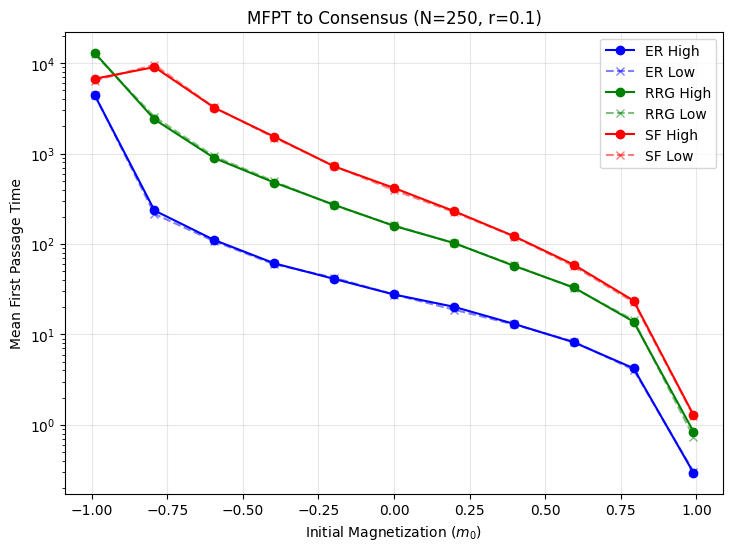

In [4]:
# --- 3. Plot ---
plt.figure(figsize=(8.5, 6))

plt.yscale('log')

# Plot ER
plt.plot(m0_er_h, mfpt_er_h, 'o-', color='blue', label='ER High')
plt.plot(m0_er_l, mfpt_er_l, 'x--', color='blue', alpha=0.5, label='ER Low')

# Plot RRG
plt.plot(m0_rg_h, mfpt_rg_h, 'o-', color='green', label='RRG High')
plt.plot(m0_rg_l, mfpt_rg_l, 'x--', color='green', alpha=0.5, label='RRG Low')

# Plot SF
plt.plot(m0_sf_h, mfpt_sf_h, 'o-', color='red', label='SF High')
plt.plot(m0_sf_l, mfpt_sf_l, 'x--', color='red', alpha=0.5, label='SF Low')

plt.xlabel(r'Initial Magnetization ($m_0$)')
plt.ylabel('Mean First Passage Time')
plt.title(f'MFPT to Consensus (N={N}, r={r_val})')
plt.grid(True, alpha=0.3)
plt.legend()

# Save
plt.savefig("../figures/mfpt_vs_m0_complex_1side.pdf")
plt.show()